# Sesión 9: Regresión Logística para Clasificación Binaria

**Objetivos:**
-   Entender la diferencia entre un problema de regresión y uno de clasificación.
-   Visualizar por qué la Regresión Lineal no es adecuada para clasificación.
-   Comprender el rol de la **función sigmoide** para convertir una salida en una probabilidad.
-   Interpretar la **Matriz de Confusión** para evaluar el rendimiento de un clasificador.
-   Analizar el impacto de modificar el **umbral de decisión** en los resultados del modelo.

## 1. De la Regresión a la Clasificación

Hasta ahora, hemos predicho valores continuos (precios, costes...). Ahora, queremos predecir una categoría discreta. La clasificación más simple es la **binaria**, donde solo hay dos posibles resultados:
-   Sí / No
-   Fraude / No Fraude
-   Enfermo / Sano

### ¿Por qué no podemos usar una Regresión Lineal?

Imagina que asignamos 0 a "Sano" y 1 a "Enfermo". Si ajustamos una línea recta, ocurren problemas:
1.  **Predicciones sin sentido**: La línea puede predecir valores mayores que 1 o menores que 0, que no tienen interpretación.
2.  **Mala adaptación**: Una línea recta no se ajusta bien a una distribución de datos que se agrupan en 0 o en 1.



### La Solución: La Función Sigmoide

La Regresión Logística resuelve esto de una manera ingeniosa. En lugar de que la salida del modelo sea la línea recta, pasa esa salida a través de una función con forma de "S", la **función sigmoide**.

$P(y=1) = \frac{1}{1 + e^{-z}}$

Donde $z$ es la salida de la regresión lineal ($z = \beta_0 + \beta_1x_1 + ...$)

Esta función "aplasta" cualquier valor de entrada y lo convierte en un número **entre 0 y 1**, que podemos interpretar como una **probabilidad**.



Si la probabilidad es > 0.5, predecimos la clase 1. Si es < 0.5, predecimos la clase 0. La línea imaginaria donde la probabilidad es exactamente 0.5 se llama **frontera de decisión (decision boundary)**.

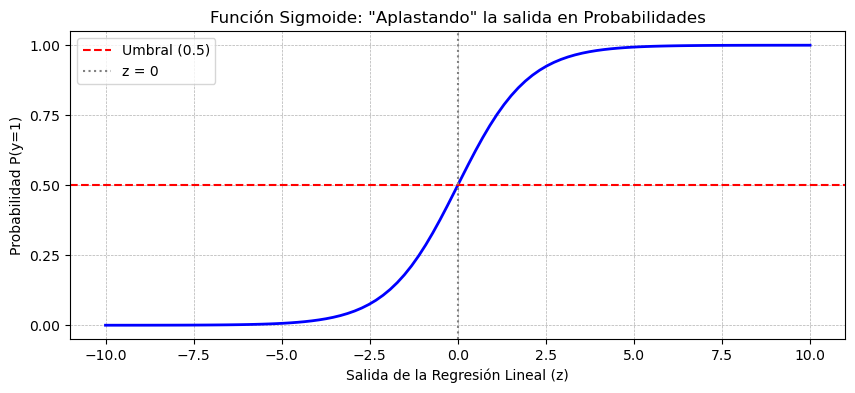

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Definimos la función sigmoide
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 1. Creamos un rango de valores para 'z'
# 'z' representa la salida de la regresión lineal (ej. de -10 a 10)
z = np.linspace(-10, 10, 100)

# 2. Calculamos la probabilidad para cada 'z' usando la sigmoide
p = sigmoid(z)

# 3. Graficamos el resultado
plt.figure(figsize=(10, 4))
plt.plot(z, p, color='blue', lw=2)

# Añadimos la frontera de decisión (0.5)
plt.axhline(0.5, color='red', linestyle='--', label='Umbral (0.5)')
plt.axvline(0, color='grey', linestyle=':', label='z = 0')

# Configuramos el gráfico
plt.title('Función Sigmoide: "Aplastando" la salida en Probabilidades')
plt.xlabel('Salida de la Regresión Lineal (z)')
plt.ylabel('Probabilidad P(y=1)')
plt.yticks([0, 0.25, 0.5, 0.75, 1.0])
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

In [3]:
# 1. Carga de Datos y Configuración Inicial
# -------------------------------------------
import pandas as pd
import numpy as np

# Dataset: Diagnóstico de Enfermedad Cardíaca
# Objetivo: Predecir si un paciente tiene una enfermedad cardíaca (target=1) o no (target=0).
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'
# Este dataset no tiene cabecera, así que definimos los nombres de las columnas
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
           'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
df = pd.read_csv(url, names=columns)

In [4]:
# 2. Inspección Clave de los Datos
# ----------------------------------
print("Primeras filas del dataset")
print(df.head())
print("Tipos de dato")
print(df.info())

print("No hay valores null pero aparecen con ?")
print((df == '?').sum())

Primeras filas del dataset
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca thal  target  
0    3.0  0.0  6.0       0  
1    2.0  3.0  3.0       2  
2    2.0  2.0  7.0       1  
3    3.0  0.0  3.0       0  
4    1.0  0.0  3.0       0  
Tipos de dato
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non

In [5]:
# 3. Preprocesamiento de Datos
# -----------------------------
print("Pasamos los ? a null y los eliminamos, Los valores ? indican pruebas medicas que no se han realizado, por lo tanto no seria buena idea rellenar esos resultados con valores falsos")
df = df.replace('?', np.nan)
df = df.dropna()
print("Al borrar se han quedado las columnas ca y thal con un tipo de dato indeterminado, pasamos todas las columnas a float")
df = df.astype(float)

print("La variable target indica si el paciente esta enfermo o no, por lo tanto el valor debe ser 0 o 1")
df['target'] = (df['target'] != 0).astype(int)
print(df['target'].value_counts())



Pasamos los ? a null y los eliminamos, Los valores ? indican pruebas medicas que no se han realizado, por lo tanto no seria buena idea rellenar esos resultados con valores falsos
Al borrar se han quedado las columnas ca y thal con un tipo de dato indeterminado, pasamos todas las columnas a float
La variable target indica si el paciente esta enfermo o no, por lo tanto el valor debe ser 0 o 1
target
0    160
1    137
Name: count, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split

# 4. Preparación Final para el Modelo
# -----------------------------------
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## 2. La Matriz de Confusión: Entendiendo los Errores

En clasificación, la precisión (accuracy) no lo es todo. Necesitamos saber **qué tipo de errores** comete nuestro modelo. Para eso, usamos la **Matriz de Confusión**.

-   **Verdaderos Positivos (TP)**: El modelo predice **1** y la realidad era **1**. (Acierto: diagnosticamos correctamente a un enfermo).
-   **Verdaderos Negativos (TN)**: El modelo predice **0** y la realidad era **0**. (Acierto: diagnosticamos correctamente a un sano).
-   **Falsos Positivos (FP) / Error Tipo I**: El modelo predice **1** pero la realidad era **0**. (Falsa Alarma: diagnosticamos a un sano como enfermo).
-   **Falsos Negativos (FN) / Error Tipo II**: El modelo predice **0** pero la realidad era **1**. (El Peor Error: diagnosticamos a un enfermo como sano).

## ACTIVIDAD EN CLASE: Modelo Base y Diagnóstico

**Tu Tarea:**
1.  **Entrena un modelo** de `LogisticRegression` con los datos de entrenamiento (`random_state=42`).
2.  **Realiza predicciones** sobre el conjunto de prueba `X_test`.
3.  **Calcula la matriz de confusión** usando `confusion_matrix(y_test, y_pred)`.
4.  **Visualiza la matriz de confusión** usando `ConfusionMatrixDisplay`.
5.  **Interprétala**: En una celda de texto, responde:
    * ¿Cuántos pacientes sanos fueron clasificados correctamente (TN)?
    * ¿Cuántos pacientes enfermos fueron clasificados correctamente (TP)?
    * ¿Cuántos "Falsos Negativos" hubo? ¿Qué significa este error en el contexto de este problema?

In [7]:
from sklearn.linear_model import LogisticRegression
# 1. Entrena un modelo de Regresión Logística
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

c:\Users\rotap\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=42)

In [8]:
# 2. Realiza predicciones
y_pred = model.predict(X_test)

In [9]:
from sklearn.metrics import confusion_matrix
# 3. Calcula la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
cm

array([[32,  4],
       [ 3, 21]])

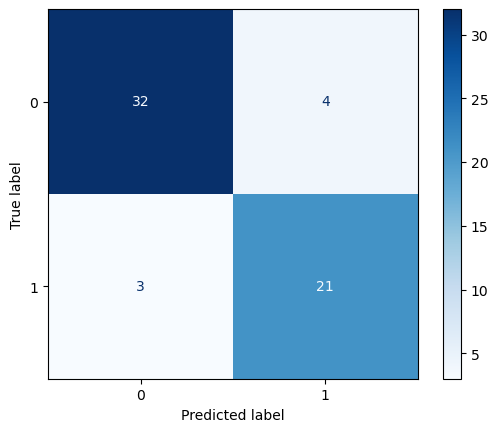

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay

# 4. Visualiza la matriz
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.show()


### Mi Interpretación de la Matriz de Confusión

*(Escribe aquí tus respuestas a la pregunta 5)*

---
## Actividad sesión 2: El Dilema del Umbral de Decisión

Por defecto, la regresión logística usa un umbral de **0.5**: si la probabilidad es > 0.5, predice 1; si no, predice 0. Pero, ¿y si movemos ese umbral?

**Tu misión:**
Vas a explorar cómo cambia la matriz de confusión al ajustar el umbral.

1.  Obtén las **probabilidades** de predicción para el conjunto de prueba usando `model.predict_proba(X_test)`. Esto te dará un array con dos columnas (prob de 0, prob de 1). Nos interesa la segunda columna.
2.  **Crea dos nuevas listas de predicciones**:
    * **Modelo Sensible (Umbral Bajo = 0.3)**: Considera una predicción como 1 si la probabilidad es > 0.3.
    * **Modelo Específico (Umbral Alto = 0.7)**: Considera una predicción como 1 si la probabilidad es > 0.7.
3.  **Calcula y visualiza la matriz de confusión** para cada uno de estos dos nuevos conjuntos de predicciones.

### Preguntas Finales para la Reflexión

1.  Compara las tres matrices de confusión (umbral 0.5, 0.3 y 0.7). ¿Cómo afectó cada cambio al número de Falsos Positivos y Falsos Negativos?
2.  Imagina dos escenarios en un hospital:
    * **Escenario A (Screening)**: Un test de cribado masivo para identificar a cualquier persona que *pudiera* tener la enfermedad para hacerle más pruebas.
    * **Escenario B (Confirmación)**: Un test para confirmar el diagnóstico antes de autorizar una operación a corazón abierto muy arriesgada.
    
    ¿Qué umbral (0.3 o 0.7) recomendarías para cada escenario y por qué?
3.  La sesión 14 del curso se dedica a "Métricas de evaluación + matriz de confusión".  Basado en este ejercicio, ¿por qué crees que una métrica simple como la "Accuracy" (porcentaje de aciertos) a menudo no es suficiente para evaluar un modelo de clasificación?

In [11]:
# ESPACIO PARA EL CÓDIGO DEL RETO PARA CASA
# TU CÓDIGO AQUÍ

### Mis Reflexiones

*(Escribe aquí tus respuestas a las preguntas del reto para casa)*

##  Ejercicio Extra: Predicción de Diabetes (El Desafío de los Datos Ocultos)

En este ejercicio, aplicaremos la Regresión Logística a un dataset de salud para predecir si una paciente tiene diabetes (`Outcome` = 1) o no (`Outcome` = 0).

**El Objetivo:** Construir un modelo que clasifique correctamente a las pacientes.

**Factor a tener en cuenta:**
1.  **El Dataset Engañoso:** A primera vista, todos los datos son numéricos y no hay `NaN` (nulos).


### Tu Tarea
Sigue los siguientes pasos:

**1. Carga y Exploración:**
* Carga el dataset desde esta URL: `https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv`
* Añade manualmente las cabeceras: `['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']`.
* Usa `.describe()` y `.info()` para inspeccionar los datos y localizar el problema de los ceros.

**2. Preprocesamiento (La Clave):**

**3. Entrenamiento y Evaluación del Modelo:**

**4. Análisis y Reflexión **
Observa tu matriz de confusión. En un contexto médico, los errores no son todos iguales.
* **Pregunta 1:** ¿Cuál es el error "peor" en este escenario?
    * **Falso Positivo (FP):** Predecir "Diabetes" a una paciente "Sana". (Genera ansiedad y costes de pruebas adicionales).
    * **Falso Negativo (FN):** Predecir "No Diabetes" (Sana) a una paciente que "Tiene Diabetes". (Muy peligroso, la paciente no recibe tratamiento).
* **Pregunta 2:** Si tu objetivo principal fuera **minimizar los Falsos Negativos (FN)** (pillar al máximo número de pacientes que SÍ tienen diabetes), ¿qué harías con el umbral de decisión? ¿Lo **subirías** (ej. a 0.7) o lo **bajarías** (ej. a 0.3)? Explica tu razonamiento.